<hr size=5 color='#002883'>

<p align="center"> <font size=7 color='#002883'> Elaboração de cartas sinóticas para identificação da Zona de Corvengência Inter-Tropical (ZCIT)

<hr size=5 color='#002883'>

<p align="left"> <font size=5 color='#002883'> Professores:  

* Prof. Dra. Rita Yuri Ynoue

<p align="left"> <font size=5 color='#002883'> Monitor PAE:

* Ronald Guiuseppi Ramírez Nina [PhD. Candidate in Atmospheric Sciences]
* email: ronald.ramirez.nina@alumni.usp.br / ronald.ramirez.nina@usp.br

<hr size=5 color='#002883'>

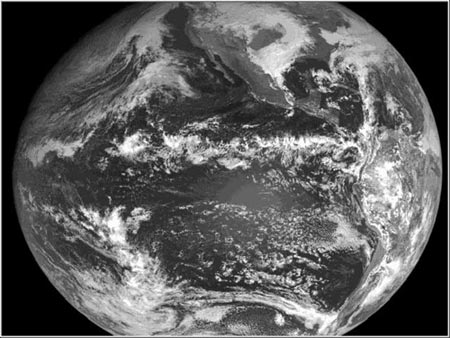

**Source:** https://www.noaa.gov/jetstream/tropical/convergence-zone

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **1. preparação do Colab** <font>

<font size=4 color='#002883'> Executar as três células de abaixo: <font>

<font size=4 color='#002883'>1.1. Montar o drive para acesso a nossa pasta de trabalho <font>

In [2]:
# @title #### <font color='#002883'> Montar o drive para a importação da livraria utilities_new_version <font>
%%capture

from google.colab import drive
drive.mount('/content/drive')

<font size=4 color='#002883'>1.2. Adicionar o caminho do sistema para a importação do utilities_new_version.py <font>

In [3]:
# @title #### <font color='#002883'> Adicionar o caminho do Drive ao caminho do sistema para importação de módulos <font>
%%capture

import sys
sys.path.append('/content/drive/MyDrive/')

<font size=4 color='#002883'>1.3. Instaçaão de livrarias <font>

In [4]:
# @title #### <font color='#002883'> Instalar livrarias <font>
%%capture

!pip install imgaug
!pip install siphon

# Instalando a Biblioteca Pygrib
!pip install pygrib
#print('\n')

# Instalando a Biblioteca Cartopy
!pip install cartopy
!pip install shapely --no-binary shapely --force
#print('\n')

# Instalando a Biblioteca MetPy
!pip install "numpy<2.0" metpy --upgrade
#!pip install MetPy
#print('\n')

# Instalando a Biblioteca Boto3
!pip install boto3
#print('\n')

# Instalando a Biblioteca NetCDF4
!pip install netcdf4
#print('\n')

# Instalando / atualizando a Biblioteca GDAL
!apt-add-repository -y ppa:ubuntugis/ubuntugis-unstable
!add-apt-repository -y ppa:ubuntugis/ppa
!apt-get install gdal-bin
!pip install 'gdal==3.0.4'
#print('\n')

# Install ImageMagick
!sudo apt install imagemagick
#print('\n')

<font size=4 color='#002883'>1.4. Reiniciar a sessão de trabalho. Necessário para a importação do módulo de Metpy <font>

In [ ]:
# @title #### <font color='#002883'> Reiniciar sessão devido ao modulo do Metpy <font>
%%capture

import os
os.kill(os.getpid(), 9)

<font size=4 color='#002883'> **2. Fazer downloand de arquivos complementários (e.g., shapefile de estados e provincias do Brasil e outros paises). Além disso, fazer o download do arquivo utilities.py para o uso no processamento de imagens de satélite da série GOES. Download do arquivo CPT para o realce do canal infravermelho e vapor d'água.** <font>

In [1]:
# @title #### <font color='#002883'> Baixar arquivos complementários <font>
%%capture

# Baixando o shapefile dos estados brasileiros
!wget -c https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
#print('\n')

# Descomprimindo o arquivo de shapefile dos estados brasileiros
!unzip -o br_unidades_da_federacao.zip
#print('\n')

# Baixando o shapefile dos estados / províncias mundiais
!wget -c https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/10m/cultural/ne_10m_admin_1_states_provinces.zip
#print('\n')

# Descomprimindo o arquivo de shapefile dos estados / províncias mundiais
!unzip -o ne_10m_admin_1_states_provinces.zip
#print('\n')

# Download do script "utilities.py", do curso de processamento de satélites, com algumas funções que facilitam a manipulação de dados de satélite
#!wget -c https://www.dropbox.com/s/i8j1g9xg1g7o56l/utilities.py
#print('\n')

# Download da arquivo CPT exemplo (para realce de canais IR)
!wget -c https://www.dropbox.com/s/fdgnaqt91cy3x97/IR4AVHRR6.cpt
#print('\n')

# Download da arquivo CPT exemplo (para realce de canais WV)
!wget -c https://www.dropbox.com/s/4l9fys6pv5c68xk/SVGAWVX_TEMP.cpt
#print('\n')

<font size=4 color='#002883'> **3. Importar livrarias.** <font>

In [2]:
# @title #### <font color='#002883'> Importar livrarias para o processamento dos dados <font>
%%capture

from datetime import datetime
import os
import requests
import time as t

# Livrarias para leitura, processamento e plot de dados NetCDF
from netCDF4 import Dataset
from osgeo import gdal
import matplotlib.pyplot as plt
import cartopy, cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import os
import numpy as np
from matplotlib import cm
from datetime import timedelta, date, datetime
import pygrib
gdal.PushErrorHandler('CPLQuietErrorHandler')

# Livrarias para o cálculo de campos meteorológicos
from metpy.units import units
import metpy.calc as mpcalc
import numpy.ma as ma

# Carregar a nova versão do utilities_new_version.py
import sys
folder_path = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-II-2026'
if folder_path not in sys.path:
    sys.path.append(folder_path)
from utilities_new_version import download_CMI
from utilities_new_version import reproject
from utilities_new_version import loadCPT

<font size=4 color='#002883'> **4. Função para o download dos dados do modelo Global forecasting System (GFS).** <font>

In [3]:
# @title #### <font color='#002883'> Construir função para o download dos arquivos do GFS <font>
%%capture

# Link (select "grib filter" and check "Show the URL only for web programming" to verify the URL's):
# https://nomads.ncep.noaa.gov/

def download_gfs(date, iii):

    # Create the URL's based on the resolution
    if (resolution == '25'):
        url = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_0p'+resolution+'.pl?file=gfs.t'+hour_run+'z.pgrb2.0p'+resolution+'.f'+str(hour).zfill(3)+'&all_lev=on&all_var=on&subregion=&leftlon='+min_lon+'&rightlon='+max_lon+'&toplat='+max_lat+'&bottomlat='+min_lat+'&dir=%2Fgfs.'+date+'%2F'+hour_run+'%2Fatmos'
        file_name = 'gfs.t'+hour_run+'z.pgrb2.0p'+resolution+'.f'+str(hour).zfill(3)
        res = 'prgb2.0p'+resolution+'.f'
    elif (resolution == '50'):
        url = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_0p'+resolution+'.pl?file=gfs.t'+hour_run+'z.pgrb2full.0p'+resolution+'.f'+str(hour).zfill(3)+'&all_lev=on&all_var=on&subregion=&leftlon='+min_lon+'&rightlon='+max_lon+'&toplat='+max_lat+'&bottomlat='+min_lat+'&dir=%2Fgfs.'+date+'%2F'+hour_run+'%2Fatmos'
        file_name = 'gfs.t'+hour_run+'z.pgrb2.0p'+resolution+'.f'+str(hour).zfill(3)
        res = 'prgb2.0p'+resolution+'.f'
    elif (resolution == '1'):
        url = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_'+resolution+'p00.pl?file=gfs.t'+hour_run+'z.pgrb2.'+resolution+'p00.f'+str(hour).zfill(3)+'&all_lev=on&all_var=on&subregion=&leftlon='+min_lon+'&rightlon='+max_lon+'&toplat='+max_lat+'&bottomlat='+min_lat+'&dir=%2Fgfs.'+date+'%2F'+hour_run+'%2Fatmos'
        file_name = 'gfs.t'+hour_run+'z.pgrb2.'+resolution+'p00.f'+str(hour).zfill(3)
        res = 'prgb2.'+resolution+'p00.f'

    # Print the file name
    print("File name: ", file_name)
    # Sends a GET request to the specified url
    myfile = requests.get(url)

    # Download the file
    open(dir + '//' + file_name, 'wb').write(myfile.content)

<font size=4 color='#002883'> **5. Download dos dados do modelo Global forecasting System (GFS). É necessário editar a data Year = YYYY, month = mm, day = dd e hour = hh. Os dados do GFS só estão disponíveis até 5 dias atrás da data atual.** <font>

In [4]:
# @title #### <font color='#002883'> Download dos dados do GFS <font>
%%capture

# Configurar a data de acesso aos dados do GFS
year = 2026
month = 8
day = 6
hour = 00

print('---------------------------------------')
print('GFS Download (NOMADS) - Script started.')
print('---------------------------------------')

# Start the time counter
start_time = t.time()

# Data desejada (Únicamente os últimos 10 dias!): Formato - 'YYYY, MM, DD, HH'
dt = datetime(year, month, day, hour)
yyyymmddhhmn = (f'{dt:%Y%m%d%H}00') # Data e hora da imagem de satélite

#-----------------------------------------------------------------------------------------------------------

# Download diretório
dir = "Samples"; os.makedirs(dir, exist_ok=True)

# Data desajada (Únicamente os últimos 10 dias!): Formato - 'YYYYMMDD'
date = (f'{dt:%Y%m%d}')

# Extensão desejada - COLOCAR AQUI ENTRE ASPAS POIS É UMA STRING
# longitude de -180 a 180
min_lon = '-122.50'
max_lon = '12.50'
min_lat = '-25.0'
max_lat = '25.0'

# Resolução espacial desejada: '25' or '50' or '1'
resolution = '1'

# Hora de execução: '00' or '06' or '12' or '18'
#hour_run = '00'
hour_run=(f'{dt:%H}')

# Horas de previsão
hour_ini = 0  # Init time
hour_end = 0 # End time
hour_int = 3  # Interval

if (resolution == '25'):
  res = 'pgrb2.0p'+resolution+'.f'
elif (resolution == '50'):
  res = 'pgrb2.0p'+resolution+'.f'
elif (resolution == '1'):
  res = 'pgrb2.'+resolution+'p00.f'

#-----------------------------------------------------------------------------------------------------------

# Download loop
for hour in range(hour_ini, hour_end + 1, hour_int):
    print('\n---------------------')
    print('Downloading GFS File:')
    print('---------------------')
    print('Resolution: ' + resolution)
    print('Date: ' + date)
    print('Run: ' + hour_run)
    print('Forecast Hour: f' + str(hour).zfill(3))
    # Call the download function
    download_gfs(date,hour)

# End the time counter
print('\nTotal Processing Time:', round((t.time() - start_time),2), 'seconds.')

<font size=4 color='#002883'> **6. Download dos dados de satélite do GOES-19.** <font>

In [5]:
# @title #### <font color='#002883'> Download de GOES-19 <font>
%%capture

# Seleção da extensão [min. lon, min. lat, max. lon, max. lat]
# Lembrar que longitude está definida entre -180 e 180
extent = [float(min_lon), float(min_lat), float(max_lon), float(max_lat)]

# Input e output directorios
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

#-----------------------------------------------------------------------------------------------------------
date = (f'{dt:%Y%m%d}')
yyyymmddhhmn = (f'{dt:%Y%m%d%H}00') # Data e hora da imagem de satélite
hour_run=(f'{dt:%H}')

# Download the ABI file channel 13 - Clean IR
file_ir = download_CMI(yyyymmddhhmn, 13, input)

# Variable
var = 'CMI'
# Abrir o dado
img = gdal.Open(f'NETCDF:{input}/{file_ir}.nc:' + var)

# Ler os metadados
metadata = img.GetMetadata()
scale = float(metadata.get(var + '#scale_factor'))
offset = float(metadata.get(var + '#add_offset'))
undef = float(metadata.get(var + '#_FillValue'))
dtime = metadata.get('NC_GLOBAL#time_coverage_start')

# Carregar os dados
ds_cmi = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)

# Aplicar a escala, offset e converter de Kelvin para Graus Celcius
ds_cmi = (ds_cmi * scale + offset) - 273.15

# Reprojeção do arquivo
filename_ret = f'{output}/IR_{yyyymmddhhmn}.nc'
reproject(filename_ret, img, ds_cmi, extent, undef)

# Ler a imagem do GOES-19 reprojetada
file = Dataset(filename_ret)

# Acessar aos valores dos pixel
data = file.variables['Band1'][:]

<font size=4 color='#002883'> **7. Definir os campos meteorológicos por níveis do GFS.** <font>

In [6]:
# @title #### <font color='#002883'> Definir as variáveis do GFS por níveis <font>
%%capture

# Ler o dado grib do GFS
grib = pygrib.open(f'Samples/gfs.t{hour_run}z.{res}000')

# Selecionar a variável
mslp = grib.select(name='Pressure reduced to MSL')[0]

# Acessar informação do arquivo
init  = str(mslp.analDate)      # Init date / time
run   = str(mslp.hour).zfill(2) # Run
ftime = str(mslp.forecastTime)  # Forecast hour
valid = str(mslp.validDate)     # Valid date / time
print('Init: ' + init + ' UTC')
print('Run: ' + run + 'Z')
print('Forecast: +' + ftime)
print('Valid: ' + valid + ' UTC')

# Ler a data da região específica
# Longitude tem que estar entre 0 e 360 graus
mslp, lats, lons = mslp.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])

# Converter para hPa
mslp = mslp / 100
# Selecionar a variável
prtwt = grib.select(name='Precipitable water')[0]
prtwt = prtwt.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
u_925 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 925)[0]
# Ler a data para a região específica
u_925, lats, lons = u_925.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Selecionar a variável
v_925 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 925)[0]
# Ler a data para a região específica
v_925 = v_925.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
u_250 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 250)[0]
# Ler a data para a região específica
u_250, lats, lons = u_250.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Selecionar a variável
v_250 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 250)[0]
# Ler a data para a região específica
v_250 = v_250.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
w_850 = grib.select(name='Vertical velocity', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler a data para a região específica
w_850 = w_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Selecionar a variável
w_500 = grib.select(name='Vertical velocity', typeOfLevel = 'isobaricInhPa', level = 500)[0]
# Ler a data para a região específica
w_500 = w_500.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
temp_850 = grib.select(name='Temperature', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler a data para a região específica
temp_850 = temp_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
relhum_800 = grib.select(name='Relative humidity', typeOfLevel = 'isobaricInhPa', level = 800)[0]
# Ler a data para a região específica
relhum_800 = relhum_800.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Selecionar a variável
relhum_850 = grib.select(name='Relative humidity', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler a data para a região específica
relhum_850 = relhum_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Selecionar a variável
relhum_700 = grib.select(name='Relative humidity', typeOfLevel = 'isobaricInhPa', level = 700)[0]
# Ler a data para a região específica
relhum_700 = relhum_700.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

#-----------------------------------------------------------------------------------------------------------

# calculando umidade relativa média entre 800 e 700 hPa
relhum = (relhum_800 + relhum_850 + relhum_700)/3

# Calculando divergencia em 925 hPa
nivel=925
pressure = units('Pa')*nivel*100
u_925 = units('m/s')*u_925
v_925 = units('m/s')*v_925
# Calculando com metpy
dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)
# Compute the divergence
div_925 = mpcalc.divergence(u_925, v_925, dx=dx, dy=dy)
# quero somente convergencia
mask_conv = ma.masked_greater_equal(div_925, 0).mask
div_925[mask_conv] = np.nan

# Calculando divergencia em 250 hPa
nivel=250
pressure = units('Pa')*nivel*100
u_250 = units('m/s')*u_250
v_250 = units('m/s')*v_250
# Calculando com metpy
dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)
# Compute the divergence
div_250 = mpcalc.divergence(u_250, v_250, dx=dx, dy=dy)
# quero somente divergencia
mask_div = ma.masked_less_equal(div_250, 0).mask
div_250[mask_div] = np.nan

# Quero somente os valores negativos de omega
mask_omega = ma.masked_greater_equal(w_850, 0).mask
w_850[mask_omega] = np.nan

mask_omega = ma.masked_greater_equal(w_500, 0).mask
w_500[mask_omega] = np.nan

# Quero somente valores maiores q 40
mask_prtwt = ma.masked_less(prtwt, 40).mask
prtwt[mask_prtwt] = np.nan

<font size=4 color='#002883'> **8. Imagen de satélite + Linhas de corrente 925 hPa + Agua precipitável + omega 500 hPa** <font>

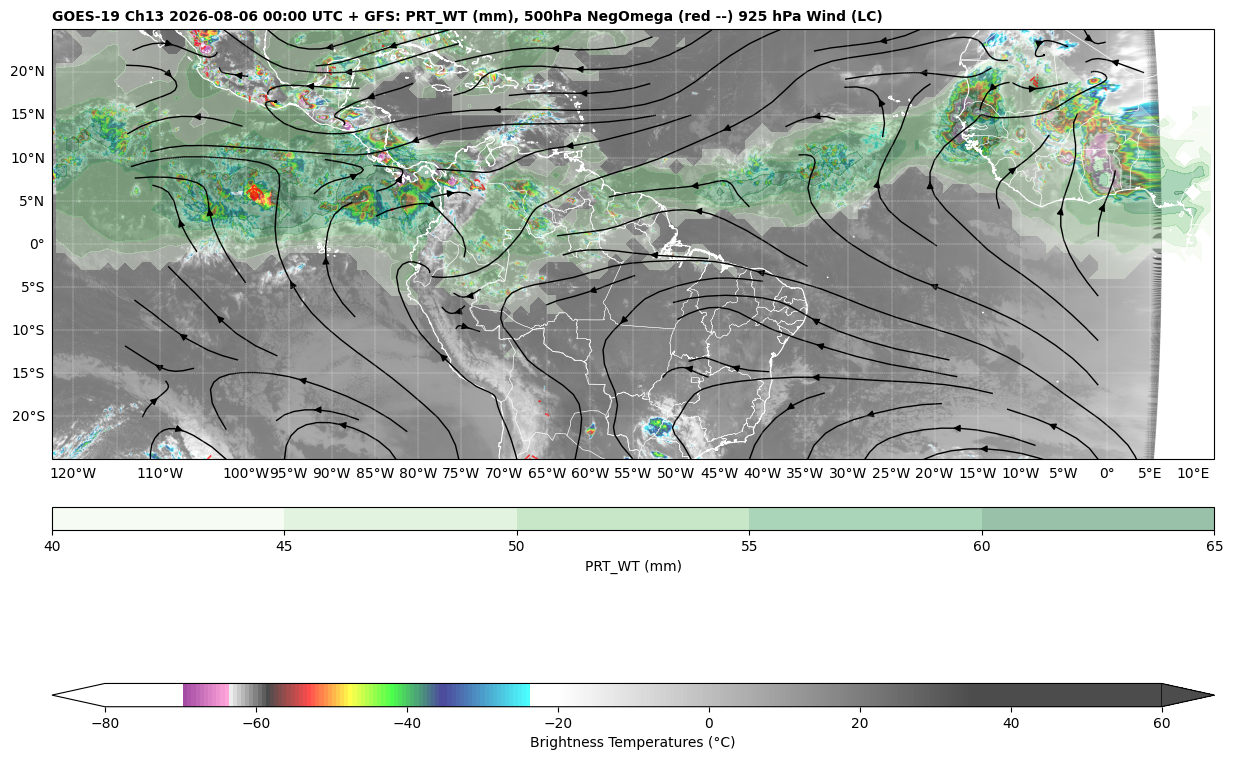

In [8]:
# @title #### <font color='#002883'> ZCIT LC 925 + PRT WT + OMEGA - Level = 500 <font>
#%%capture

# Eleição do tamanho da figura
plt.figure(figsize=(15,15))

# Usar a projeção Geoestacionária utilizando Cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão da imagem
img_extent = [extent[0], extent[2], extent[1], extent[3], ccrs.PlateCarree()]

# Definir o color da escala baseado no canal
# Converts a CPT file to be used in Python
cpt = loadCPT('IR4AVHRR6.cpt')
colormap = cm.colors.LinearSegmentedColormap('cpt', cpt)

# Plot da imagem
img1 = ax.imshow(data, origin='upper', vmin=-80, vmax=60, extent=img_extent, cmap=colormap, alpha=0.7)
# Adicionar a colorbar
plt.colorbar(img1, label='Brightness Temperatures (°C)', extend='both', orientation='horizontal', pad=0.03, aspect = 50)

# Plotando agua precipitavel acima de 40 mm
clevppt = np.arange(40, 70, 5)
cs2 = ax.contourf(lons, lats,prtwt,clevppt,cmap = 'Greens', alpha=0.4)
cb = plt.colorbar(cs2,label='PRT_WT (mm)',orientation="horizontal", pad=0.05,aspect=50)

# Plotando omega negativo
cs = ax.contour(lons, lats,w_500*1e4, colors='red', linewidths=1.25,linestyles='--',transform=ccrs.PlateCarree(), alpha=0.7)

# Adicionar as Linhas de corrente
ax.streamplot(lons, lats, u_925, v_925, density=[0.7, 1], linewidth=1, color='black')

# Add a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='white',facecolor='none', linewidth=0.3)

# Adicionar coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='white', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='white', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Extrair a data
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Adicionar o título
plt.title('GOES-19 Ch13 ' + date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' + GFS: PRT_WT (mm), 500hPa NegOmega (red --) 925 hPa Wind (LC)', fontweight='bold', fontsize=10, loc='left')

#-----------------------------------------------------------------------------------------------------------
# Salvar a imagem
plt.savefig(f'{output}/ZCIT_925LC_PrtWt_Om500.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Mostrar a imagem
plt.show()

<font size=4 color='#002883'> **9. Linhas de corrente 925 hPa + omega em 850 hPa + UR(800-700)** <font>

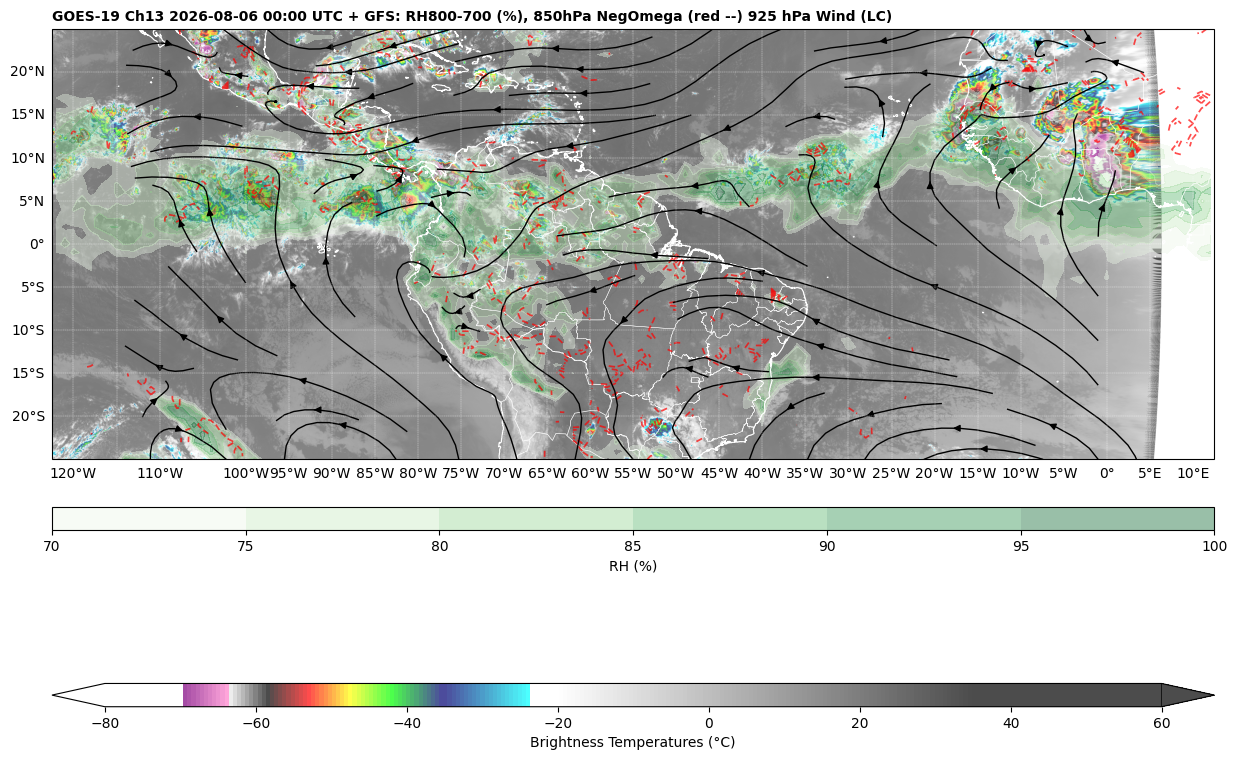

In [9]:
# @title #### <font color='#002883'> ZCIT LC 925 + UR medio (700-800hPa) + OMEGA 850 <font>
#%%capture

# Eleição do tamanho da imagem
plt.figure(figsize=(15,15))

# Usar a projeção Geoestacionária em Cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão da imagem
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Define the color scale based on the channel
# Converts a CPT file to be used in Python
cpt = loadCPT('IR4AVHRR6.cpt')
colormap = cm.colors.LinearSegmentedColormap('cpt', cpt)

# Plot da imagem
img1 = ax.imshow(data, origin='upper', vmin=-80, vmax=60, extent=img_extent, cmap=colormap, alpha=0.7)
# Adicionar a colorbar
plt.colorbar(img1, label='Brightness Temperatures (°C)', extend='both', orientation='horizontal', pad=0.03, aspect = 50)

# Plotando UR
clevrh = np.arange(70, 101, 5)
cs2 = ax.contourf(lons, lats,relhum,clevrh,cmap = 'Greens',alpha=0.4)
cb = plt.colorbar(cs2,label='RH (%)',orientation="horizontal", pad=0.05,aspect=50)

# Plotando omega negativo
cs = ax.contour(lons, lats,w_850*1e4, colors='red', linewidths=1.25,linestyles='--',transform=ccrs.PlateCarree(), alpha=0.7)

# Adicionar linhas de corrente
ax.streamplot(lons, lats, u_925, v_925, density=[0.7, 1], linewidth=1, color='black')

# Adicionar a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='white',facecolor='none', linewidth=0.3)

# Adicionar coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='white', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='white', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Extrair a data
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Adicionar o titulo
plt.title('GOES-19 Ch13 ' + date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' + GFS: RH800-700 (%), 850hPa NegOmega (red --) 925 hPa Wind (LC)', fontweight='bold', fontsize=10, loc='left')

#-----------------------------------------------------------------------------------------------------------
# Salvar a imagem
plt.savefig(f'{output}/ZCIT_925LC_RelHum_Om850.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Mostrar a imagem
plt.show()


<font size=4 color='#002883'> **10. Satélite + Linhas de corrente 925 hPa + convergência 925 hPa** <font>

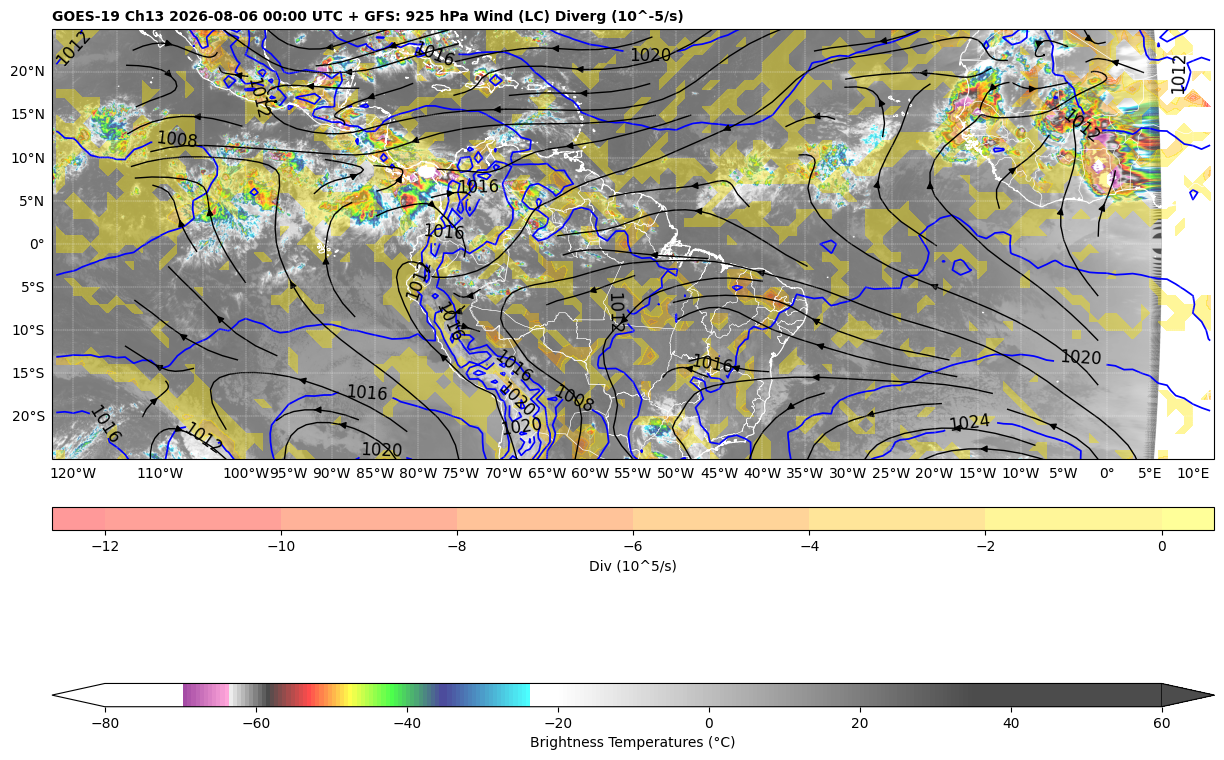

In [12]:
# @title #### <font color='#002883'> Satélite + Linhas de corrente 925 hPa + convergência 925 hPa <font>
#%%capture

# Eleição do tamanho da imagem
plt.figure(figsize=(15,15))

# Usar a projeção Geoestacionária em Cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão da imagem
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Define o color da escala baseado no canal do satélite
# Converts a CPT file to be used in Python
cpt = loadCPT('IR4AVHRR6.cpt')
colormap = cm.colors.LinearSegmentedColormap('cpt', cpt)

# Plot da imagem
img1 = ax.imshow(data, origin='upper', vmin=-80, vmax=60, extent=img_extent, cmap=colormap, alpha=0.7)
# Adicioanr a colorbar
plt.colorbar(img1, label='Brightness Temperatures (°C)', extend='both', orientation='horizontal', pad=0.03, aspect = 50)

# Plot MSLP
clevmslp = np.arange(800., 1120., 4)
cs = ax.contour(lons, lats, mslp, clevmslp, colors='blue', linewidths=1.25,linestyles='solid',transform=ccrs.PlateCarree())
ax.clabel(cs, fontsize=12, colors='black', inline=1, inline_spacing=8,
          fmt='%i', rightside_up=True, use_clabeltext=True)

# Plot o colorfill da divergência, escalado 10^5 every 1 s^1
clevdiv = np.arange(-12, 0.5, 2)
cs1 = ax.contourf(lons, lats, div_925*1e5, clevdiv, cmap='autumn', alpha = 0.4,
                  extend='both', transform=ccrs.PlateCarree())
# Adicionar o colorbar
plt.colorbar(cs1, label='Div (10^5/s)',orientation='horizontal', pad=0.05, aspect=50, extendrect=True)

# Adicionar as linhas de corrente
ax.streamplot(lons, lats, u_925, v_925, density=[0.7, 1], linewidth=1, color='black')

# Adicionar a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='white',facecolor='none', linewidth=0.3)

# Adicionar coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='white', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='white', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Extrair a data
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Adicionar o titulo
plt.title('GOES-19 Ch13 ' + date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' + GFS: 925 hPa Wind (LC) Diverg (10^-5/s)', fontweight='bold', fontsize=10, loc='left')

#-----------------------------------------------------------------------------------------------------------
# Salvar a imagem
plt.savefig(f'{output}/ZCIT_925LC_Div.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Mostrar a imagem
plt.show()


<font size=4 color='#002883'> **Satélite + linhas de corrente 250 hPa + divergência 250 hPa** <font>

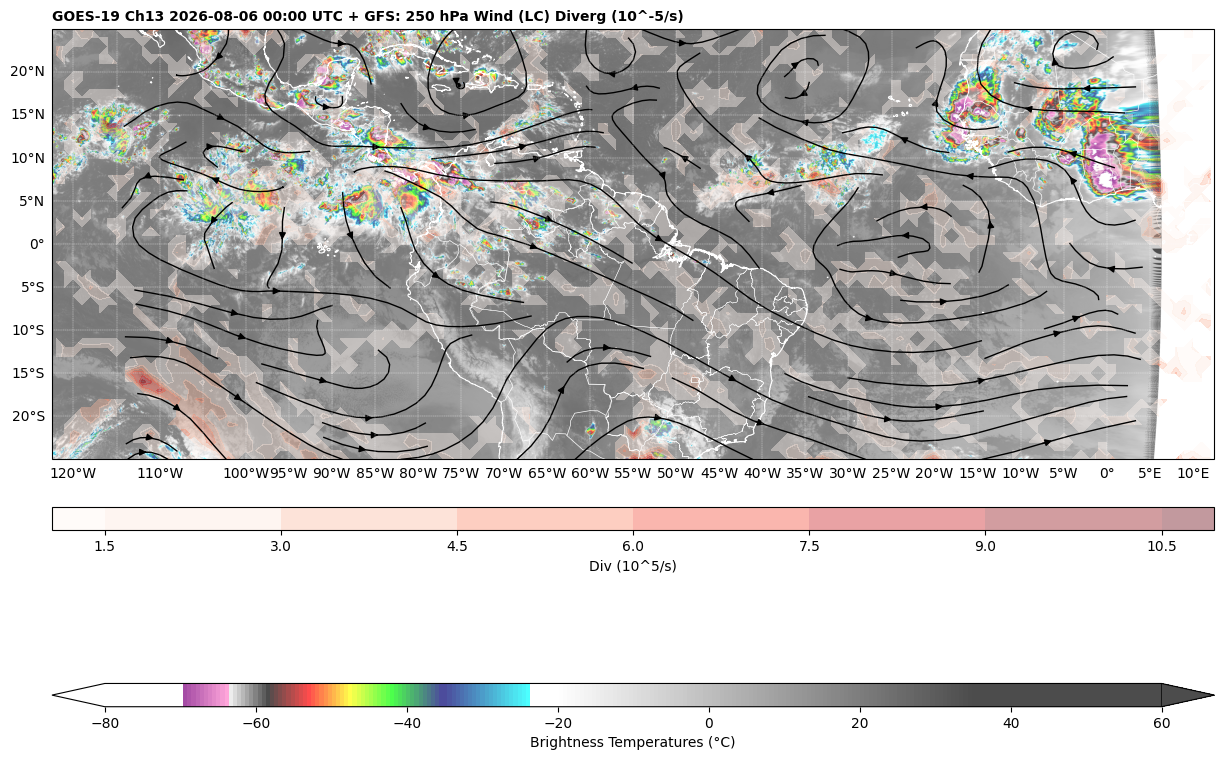

In [13]:
# @title #### <font color='#002883'> Satélite + linhas de corrente 250 hPa + divergência 250 hPa <font>
#%%capture

# ZCIT div 250
# Eleição do tamanho da imagem
plt.figure(figsize=(15,15))

# Uso da projeção Geoestacionária em Cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão da imagem
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Definir o color da escala baseado no canal do satélite
# Converts a CPT file to be used in Python
cpt = loadCPT('IR4AVHRR6.cpt')
colormap = cm.colors.LinearSegmentedColormap('cpt', cpt)

# Plot da imagem
img1 = ax.imshow(data, origin='upper', vmin=-80, vmax=60, extent=img_extent, cmap=colormap, alpha=0.7)
# Adicionar a colorbar
plt.colorbar(img1, label='Brightness Temperatures (°C)', extend='both', orientation='horizontal', pad=0.03, aspect = 50)

# Plot MSLP
#clevmslp = np.arange(800., 1120., 4)
#cs = ax.contour(lons, lats, mslp, clevmslp, colors='black', linewidths=1.25,linestyles='solid',transform=ccrs.PlateCarree())
#ax.clabel(cs, fontsize=12, colors='black', inline=1, inline_spacing=8,
#          fmt='%i', rightside_up=True, use_clabeltext=True)

# Plot the colorfill da divergência, escalado 10^5 every 1 s^1
cs1 = ax.contourf(lons, lats, div_250*1e5, cmap='Reds', alpha = 0.4,
                  extend='both', transform=ccrs.PlateCarree())
# Adicionar a colorbar
plt.colorbar(cs1, label='Div (10^5/s)',orientation='horizontal', pad=0.05, aspect=50, extendrect=True)

# Adicionar as linhas de corrente
ax.streamplot(lons, lats, u_250, v_250, density=[0.7, 1], linewidth=1, color='black')

# Adicionar a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='white',facecolor='none', linewidth=0.3)

# Adicionar coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='white', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='white', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Extrair a data
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Adicionar o titulo
plt.title('GOES-19 Ch13 ' + date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' + GFS: 250 hPa Wind (LC) Diverg (10^-5/s)', fontweight='bold', fontsize=10, loc='left')

#-----------------------------------------------------------------------------------------------------------
# Salvar a imagem
plt.savefig(f'{output}/ZCIT_250LC_Div.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Mostrar a imagem
plt.show()
